# K-Means Clustering From Scratch

K-Means is an **unsupervised learning** algorithm that groups data points into `K` clusters. Each point is assigned to the cluster whose **centroid** (center point) is closest to it.

The idea is simple and iterative:
1. Start with `K` random centroids.
2. **Assign** every point to its nearest centroid.
3. **Update** each centroid to be the average position of the points assigned to it.
4. Repeat steps 2-3 until the centroids stop moving (convergence).

The animation below shows this process happening on our actual dataset — watch how the centroids (black X markers) drift toward the center of their clusters, and how points switch colors as they get reassigned, until everything settles:

![K-Means Training Animation](../GIF/kmeans.gif)

In this notebook we'll implement K-Means **completely from scratch** using only NumPy, pandas, and matplotlib — no `scikit-learn`.

## 2. Load and Explore the Data

We'll use the **Mall Customers** dataset, which contains basic info about mall customers collected via membership cards.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../Data_SET/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

**About the dataset:** it has 200 rows and 5 columns — `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. There are no missing values.

There is **no target/label column** — that's expected, since clustering is unsupervised: we're trying to *discover* groups in the data, not predict a known label. The two numeric columns most useful for clustering customers by behavior are `Annual Income (k$)` and `Spending Score (1-100)`.

## 3. Select Features

We'll cluster customers using **Annual Income** and **Spending Score**. These two numeric features describe customer behavior directly, and using exactly two of them lets us visualize the clusters on a simple 2D scatter plot.

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

## 4. Feature Scaling (Manual Standardization)

K-Means relies on **Euclidean distance** to decide which centroid a point is closest to. `Annual Income` ranges up to ~137 while `Spending Score` ranges up to ~99 — but income is measured in different units entirely. If we don't scale the features, a feature with a naturally larger numeric range can dominate the distance calculation and skew the clusters.

We standardize manually so every feature has mean 0 and standard deviation 1:

```
X_scaled = (X - mean) / std
```

In [6]:
mean = X.mean(axis=0)
std = X.std(axis=0)
X_scaled = (X - mean) / std

print("Mean after scaling:", X_scaled.mean(axis=0).round(2))
print("Std after scaling:", X_scaled.std(axis=0).round(2))

Mean after scaling: [-0. -0.]
Std after scaling: [1. 1.]


## 5. The Math Behind K-Means

- **Centroids**: the center point of each cluster. We initialize them by picking `K` random data points.
- **Assignment step**: each point is assigned to its nearest centroid, using Euclidean distance:

$$ \text{distance} = \sqrt{\sum (x - centroid)^2} $$

- **Update step**: each centroid is recalculated as the mean of all points currently assigned to it.
- **Convergence**: we repeat the assignment and update steps until the centroids stop moving significantly, or a maximum number of iterations is reached.
- **Inertia** *(optional)*: the sum of squared distances between each point and its assigned centroid. K-Means tries to minimize this value.

## 6. K-Means From Scratch

We implement K-Means as a small set of simple functions, one for each step described above.

In [7]:
def initialize_centroids(X, k):
    # Pick k random data points to use as the starting centroids
    random_indices = np.random.choice(len(X), k, replace=False)
    return X[random_indices].copy()

def assign_clusters(X, centroids):
    # Compute distance from every point to every centroid, then pick the closest one
    distances = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    # Each new centroid is the mean of the points assigned to it
    new_centroids = np.zeros((k, X.shape[1]))
    for cluster_id in range(k):
        points_in_cluster = X[labels == cluster_id]
        if len(points_in_cluster) > 0:
            new_centroids[cluster_id] = points_in_cluster.mean(axis=0)
    return new_centroids

def compute_inertia(X, labels, centroids):
    # Sum of squared distances between each point and its assigned centroid
    total = 0
    for cluster_id in range(len(centroids)):
        points_in_cluster = X[labels == cluster_id]
        total += ((points_in_cluster - centroids[cluster_id]) ** 2).sum()
    return total

def kmeans(X, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, k)
    history = []      # stores (centroids, labels) at every iteration, used later for the animation
    inertias = []      # stores inertia at every iteration, used later for the training curve

    for iteration in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        inertias.append(compute_inertia(X, labels, new_centroids))
        history.append((centroids.copy(), labels.copy()))

        # Check for convergence: stop early if centroids barely moved
        centroid_shift = np.sqrt(((new_centroids - centroids) ** 2).sum())
        centroids = new_centroids
        if centroid_shift < tol:
            break

    labels = assign_clusters(X, centroids)
    history.append((centroids.copy(), labels.copy()))
    return centroids, labels, history, inertias

## 7. Training the Model

Let's run our K-Means implementation on the scaled data with a reasonable default of `K=5` and track the inertia at every iteration.

During training, points keep getting reassigned to closer centroids and centroids keep moving toward the middle of their clusters. As a result, inertia should generally **decrease** and then flatten out once the clusters stabilize.

In [8]:
np.random.seed(42)  # for reproducible results

K = 5
centroids, labels, history, inertias = kmeans(X_scaled, K)

print(f"Converged after {len(history)} iterations")
print(f"Final inertia: {inertias[-1]:.2f}")

Converged after 12 iterations
Final inertia: 65.58


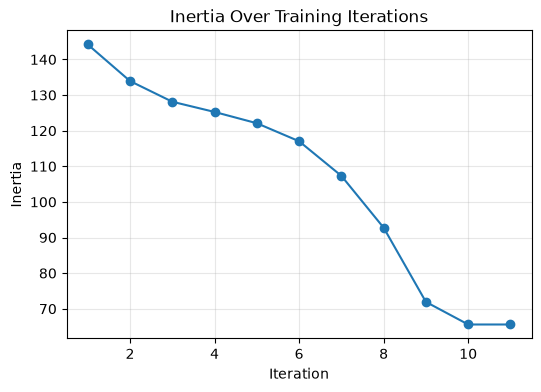

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(inertias) + 1), inertias, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("Inertia Over Training Iterations")
plt.grid(alpha=0.3)
plt.show()

## 8. Choosing K (Elbow Method)

How do we know `K=5` is a good choice? The **elbow method** runs K-Means for a range of `K` values and plots the resulting inertia. As `K` increases, inertia always decreases (more clusters mean points are closer to *some* centroid) — but past a certain point, adding more clusters gives diminishing returns.

That point, where the curve bends like an elbow, is a good choice for `K`.

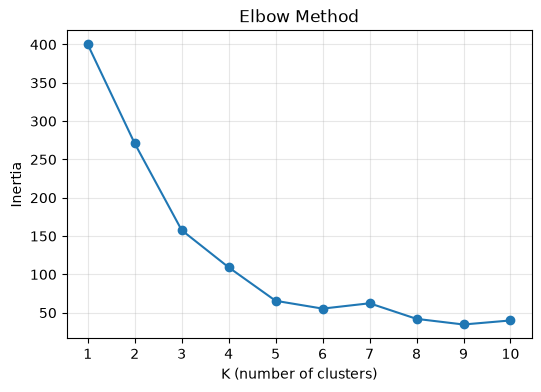

In [11]:
k_values = range(1, 11)
final_inertias = []

for k in k_values:
    _, _, _, inertia_history = kmeans(X_scaled, k)
    final_inertias.append(inertia_history[-1])

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), final_inertias, marker='o')
plt.xlabel("K (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()

**Reading the plot:** inertia drops sharply up to around `K=5`, then flattens out — adding a 6th or 7th cluster barely reduces inertia further. That bend at `K=5` is the "elbow," confirming it's a reasonable choice for this dataset.

## 9. Final Clustering and Visualization

Now we fit K-Means with our chosen `K=5` and visualize the final result: each point colored by its cluster, with the centroids marked as black stars.

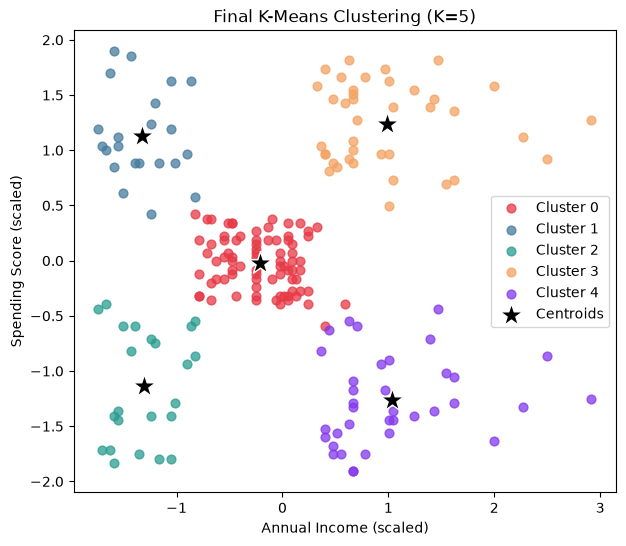

In [12]:
np.random.seed(42)
K_final = 5
final_centroids, final_labels, _, _ = kmeans(X_scaled, K_final)

plt.figure(figsize=(7, 6))
for cluster_id in range(K_final):
    points = X_scaled[final_labels == cluster_id]
    plt.scatter(points[:, 0], points[:, 1], c=colors[cluster_id % len(colors)],
                label=f'Cluster {cluster_id}', s=40, alpha=0.75)

plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='black', marker='*',
            s=300, edgecolors='white', linewidths=1, label='Centroids', zorder=5)

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title(f"Final K-Means Clustering (K={K_final})")
plt.legend()
plt.show()

## 10. Conclusion

- **K-Means** groups data into `K` clusters by repeatedly assigning points to the nearest centroid and then updating each centroid to the mean of its assigned points.
- The **assignment step** and **update step** work together: assignment groups points around the current centroids, and the update moves centroids to better represent their groups. Repeating both steps refines the clusters until they stabilize.
- **Inertia** measures how tightly packed the clusters are — it's the sum of squared distances from each point to its centroid, and K-Means tries to minimize it.
- The **elbow method** helps pick a good `K` by looking for the point where adding more clusters stops meaningfully reducing inertia.
- The **final clusters** in our case represent groups of mall customers with similar income and spending behavior — useful, for example, for targeted marketing.